In [3]:
import pandas as pd

df = pd.read_csv("superstore_sample.csv")

df.head()

,Order Date,Sales,Profit,Category,Region
0,2022-01-01,122,20,Furniture,South
1,2022-01-02,455,136,Office Supplies,West
2,2022-01-03,368,192,Furniture,South
3,2022-01-04,290,35,Technology,West
4,2022-01-05,126,-23,Technology,West


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Order Date  200 non-null    object
 1   Sales       200 non-null    int64 
 2   Profit      200 non-null    int64 
 3   Category    200 non-null    object
 4   Region      200 non-null    object
dtypes: int64(2), object(3)
memory usage: 7.9+ KB


,Sales,Profit
count,200.000000,200.000000
mean,260.555000,85.960000
std,139.579508,65.844711
min,21.000000,-49.000000
25%,149.500000,39.000000
50%,260.500000,88.500000
75%,379.000000,139.000000
max,496.000000,199.000000


In [6]:
# controlla valori nulli
df.isnull().sum()

# rimuovi duplicati
df = df.drop_duplicates()

# sistema data
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [7]:
df['Sales'].sum()
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
West       17081
South      13218
Central    11222
East       10590
Name: Sales, dtype: int64

In [8]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales

Order Date
2022-01    8267
2022-02    7528
2022-03    8302
2022-04    8852
2022-05    7179
2022-06    7910
2022-07    4073
Freq: M, Name: Sales, dtype: int64

Matplotlib is building the font cache; this may take a moment.


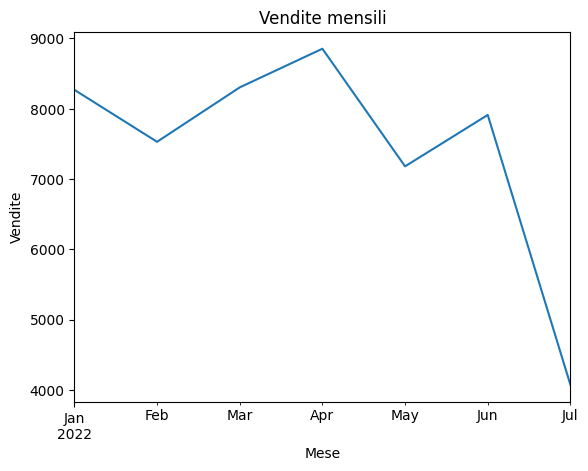

In [10]:
import matplotlib.pyplot as plt

monthly_sales.plot()
plt.title("Vendite mensili")
plt.xlabel("Mese")
plt.ylabel("Vendite")
plt.show()

## 📊 ANALISI DELLE VENDITE

### 📌 Insight principali

- Le vendite mostrano variazioni nel tempo, con alcuni mesi più performanti di altri  
- Alcune categorie di prodotti generano più revenue rispetto ad altre  
- Esistono differenze nelle vendite tra le diverse regioni  

### 💡 Considerazioni

- La presenza di picchi nelle vendite potrebbe indicare una stagionalità  
- Le categorie più profittevoli potrebbero essere potenziate con strategie di marketing  
- Le regioni meno performanti potrebbero richiedere interventi mirati  

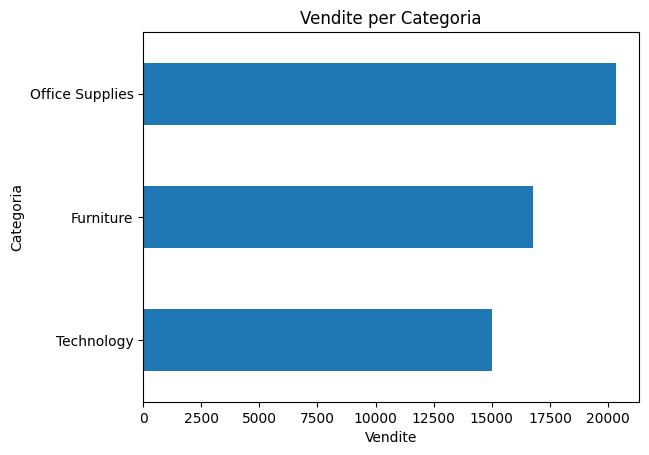

In [11]:
import matplotlib.pyplot as plt

sales_cat = df.groupby('Category')['Sales'].sum().sort_values()

sales_cat.plot(kind='barh')
plt.title("Vendite per Categoria")
plt.xlabel("Vendite")
plt.ylabel("Categoria")
plt.show()

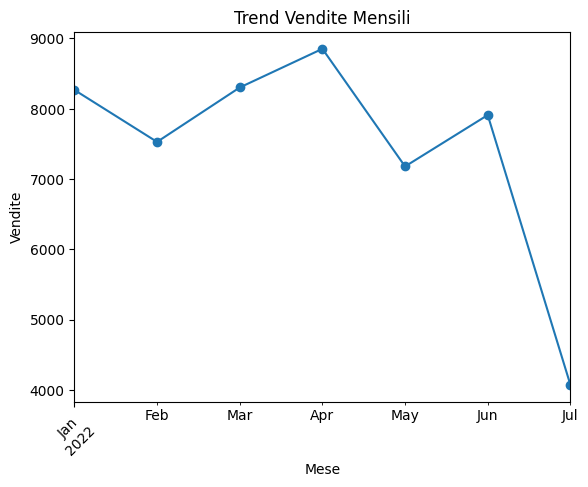

In [12]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.plot(marker='o')
plt.title("Trend Vendite Mensili")
plt.xlabel("Mese")
plt.ylabel("Vendite")
plt.xticks(rotation=45)
plt.show()

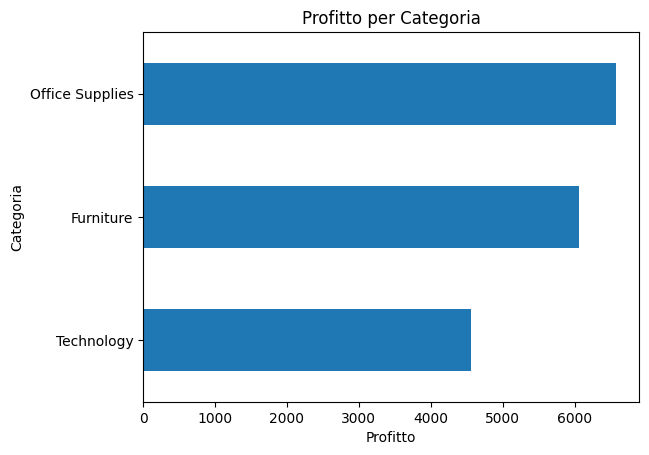

In [13]:
profit_cat = df.groupby('Category')['Profit'].sum().sort_values()

profit_cat.plot(kind='barh')
plt.title("Profitto per Categoria")
plt.xlabel("Profitto")
plt.ylabel("Categoria")
plt.show()

## 📊 ANALISI PROFITTO

### 📌 Insight

- Non tutte le categorie più vendute sono anche le più profittevoli  
- Alcune categorie generano molte vendite ma basso profitto  
- È importante distinguere tra revenue e profitto  

### 💡 Business Insight

- L’azienda dovrebbe concentrarsi su prodotti ad alto margine  
- Le categorie con alto volume ma basso profitto potrebbero avere costi elevati  

In [15]:
plt.figure()
sales_cat.plot(kind='barh')
plt.title("Vendite per Categoria")
plt.savefig("images/sales_by_category.png")
plt.close()

In [16]:
plt.figure()

monthly_sales.plot(marker='o')

plt.title("Vendite Mensili")
plt.xlabel("Mese")
plt.ylabel("Vendite")

plt.savefig("images/monthly_sales.png")

plt.close()

In [17]:
plt.figure()

profit_cat.plot(kind='barh')

plt.title("Profitto per Categoria")
plt.xlabel("Profitto")
plt.ylabel("Categoria")

plt.savefig("images/profit_by_category.png")

plt.close()

In [18]:
plt.savefig("images/monthly_sales.png")

<Figure size 640x480 with 0 Axes>

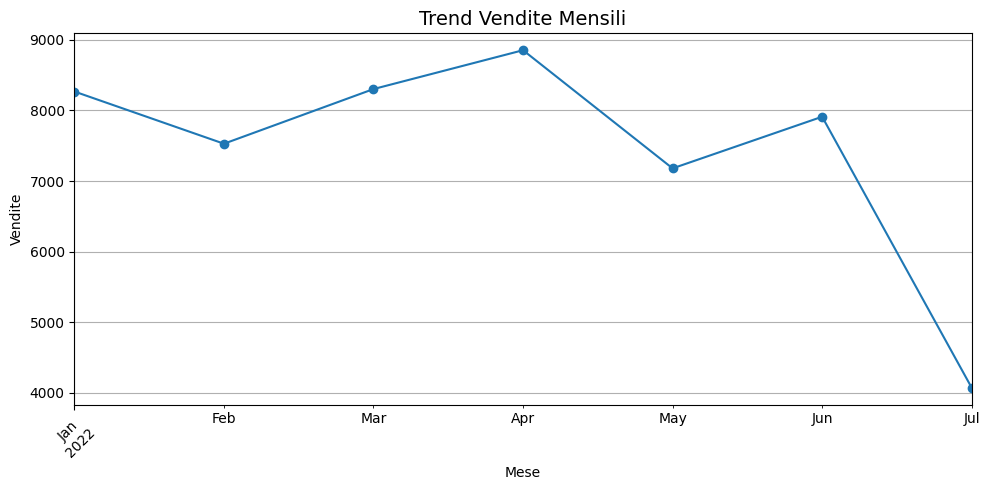

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Trend Vendite Mensili", fontsize=14)
plt.xlabel("Mese")
plt.ylabel("Vendite")

plt.grid()

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("images/monthly_sales_pro.png")

plt.show()

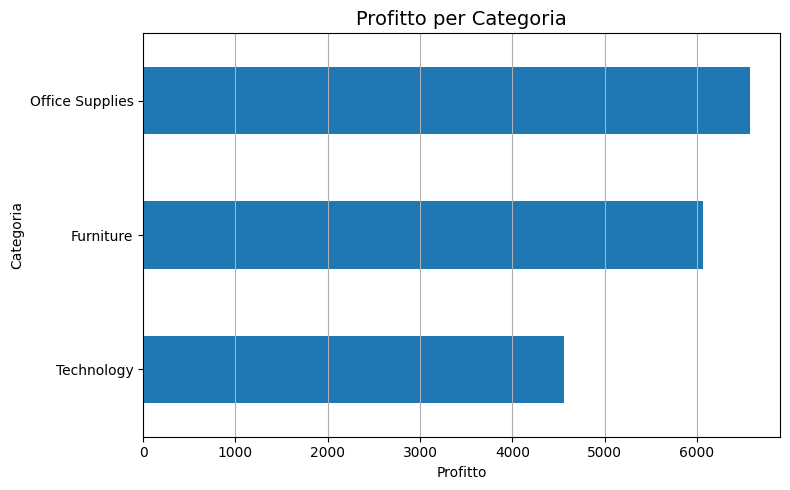

In [20]:
plt.figure(figsize=(8,5))

profit_cat.plot(kind='barh')

plt.title("Profitto per Categoria", fontsize=14)
plt.xlabel("Profitto")
plt.ylabel("Categoria")

plt.grid(axis='x')

plt.tight_layout()

plt.savefig("images/profit_pro.png")

plt.show()

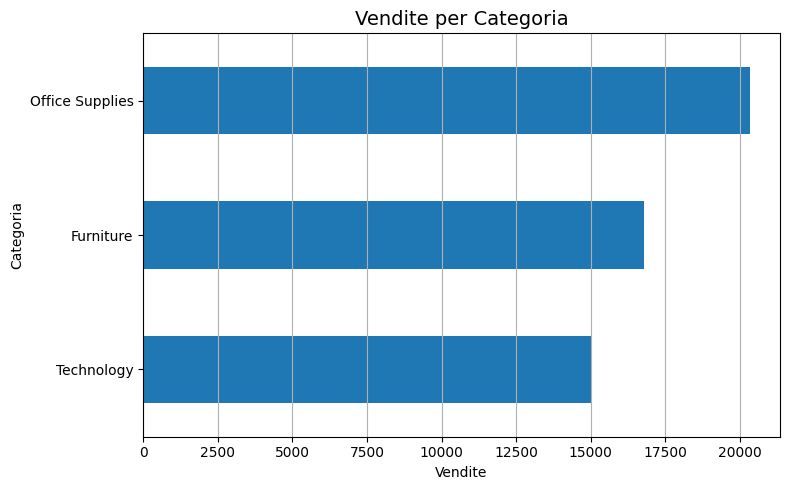

In [21]:
plt.figure(figsize=(8,5))

sales_cat.plot(kind='barh')

plt.title("Vendite per Categoria", fontsize=14)
plt.xlabel("Vendite")
plt.ylabel("Categoria")

plt.grid(axis='x')

plt.tight_layout()

plt.savefig("images/sales_pro.png")

plt.show()

## 📊 FINAL INSIGHTS

### 📌 Key Findings

- The analysis highlights differences between revenue and profitability across categories  
- Some categories generate high sales but lower profit margins  
- Sales trends suggest variability over time, indicating possible seasonal patterns  

### 💡 Business Impact

- Focus on high-margin products to improve profitability  
- Optimize low-performing categories by reducing costs or revising pricing strategies  
- Use seasonal trends to plan marketing campaigns  

### 🚀 Conclusion

This analysis demonstrates how data can support strategic business decisions by identifying trends, inefficiencies, and growth opportunities.